In [2]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 33.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

In [2]:
sm = load_samap('Active_SAMap_Joined/sm_hypo_nonneural_07262026.pkl')

In [38]:
#Change to match your organisms
org_one = 'mg'
org_two = 'dr'

In [39]:
sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn']

AAACCTGAGAGTTGGC    339 Astrocyte-like NN
AAACCTGCAAGCGTAG          338 Lymphoid NN
AAACCTGCATCACCCT    339 Astrocyte-like NN
AAACCTGGTAAGAGAG              333 Endo NN
AAACCTGTCATGTCCC                337 DC NN
                            ...          
TTTATGCGTTCGCGAC                337 DC NN
TTTCCTCAGACACTAA               326 OPC NN
TTTGCGCAGCTGAACG               326 OPC NN
TTTGCGCCAAGCCCAC          338 Lymphoid NN
TTTGTCACATGTAAGA          338 Lymphoid NN
Name: ss_subclass_v4_nounlabeled_nn, Length: 14345, dtype: object

In [40]:
#change to match celltype names
level_one = 'subclass_id_label'
level_two = 'ss_subclass_v4_nounlabeled_nn'

In [41]:
keys = {org_one:level_one,org_two:level_two}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable =  MappingTable.loc[:,[i for i in MappingTable.columns if i[:2] == org_one]]
lim_MappingTable = lim_MappingTable.loc[[i for i in lim_MappingTable.index if i[:2] == org_two],:]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [46]:
index_ord = ['dr_339 Astrocyte-like NN','dr_323 Ependymal NN', 'dr_325 CHOR NN', 'dr_326 OPC NN',
       'dr_327 Oligo NN', 'dr_328 OEC NN', 'dr_329 ABC NN', 'dr_330 VLMC NN',
       'dr_331 Peri NN', 'dr_333 Endo NN','dr_340 Macrophage NN', 'dr_337 DC NN',
       'dr_338 Lymphoid NN', 
        'dr_Unlabeled']

In [47]:
lim_MappingTable = lim_MappingTable.reindex(index_ord)

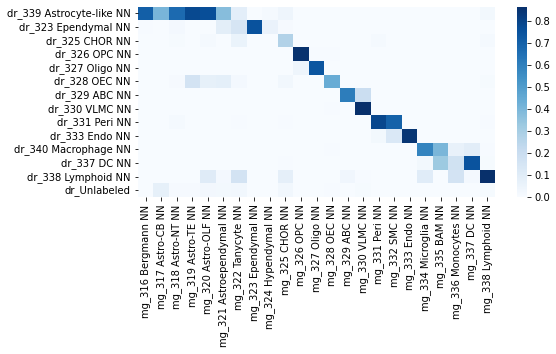

In [48]:
plt.figure(figsize = (8,len(lim_MappingTable.index)/4))
sns.heatmap(lim_MappingTable, cmap = 'Blues')
plt.savefig('Figures/Figures_08022026/DRMG_noneural_samap_08042026.pdf',bbox_inches='tight')